# Case Study: Average Order Value in an Online Store

Business Context:

An online store claims that the average order value (AOV) from customers is $75.

You collected a sample of 40 recent customer orders and want to test whether the current average differs from that claim.

Data:
order_value.csv


1. What kind of distribution are you potentially dealing with?
2. Calculate the descriptive stats
3. Plot the graphs 
4. Check normality with Q-Q plot
5. Validate with Shapiro-Wilk Test
6. Calculate CI with the appropriate method
7. Perform Hypothesis Test
8. Provide Business Interpretation


In [17]:
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.weightstats import ztest
from scipy.stats import poisson
np.random.seed(42)
import pandas as pd

In [7]:
# Read the data
df_order_value =pd.read_csv("../data/order_value.csv")

In [9]:
df_order_value.head()

,Order_Value
0,81.973713
1,76.893886
2,83.181508
3,90.184239
4,76.126773


In [10]:
df_order_value.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Order_Value  40 non-null     float64
dtypes: float64(1)
memory usage: 452.0 bytes


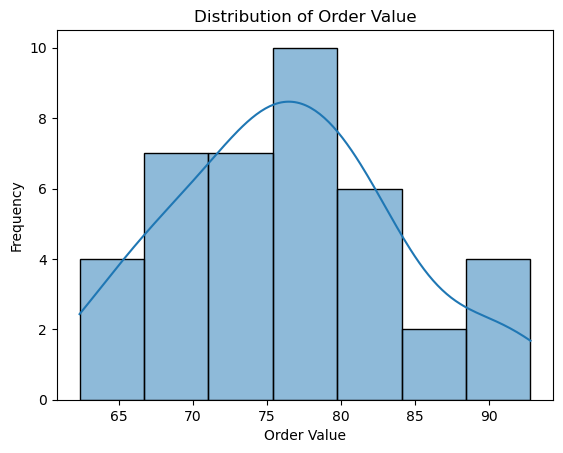

In [18]:
sns.histplot(df_order_value['Order_Value'], kde=True)
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

## Q-Q Plot Interpretation (Order Value Scenario):

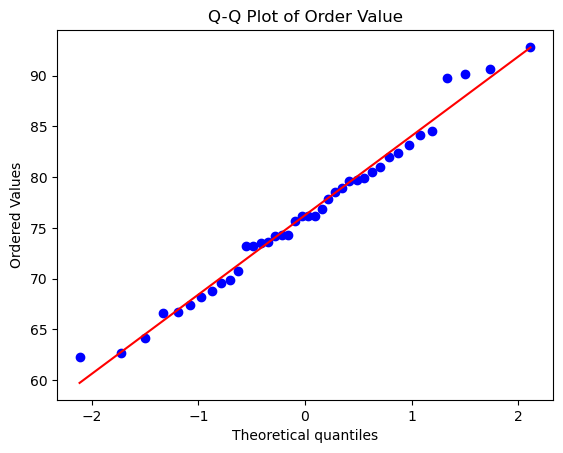

In [20]:
# Q-Q plot
stats.probplot(df_order_value['Order_Value'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Order Value")
plt.show()

In [23]:
## Q-Q Plot Interpretation (Machine Temperatures Scenario):

# Most of the points in the center of the Q-Q plot lie close to the diagonal line, 
# suggesting that the bulk of the data is approximately normal.

# A few points at the tails deviate from the diagonal, 
# indicating mild departures from normality in the extremes. This could be due to rare high or low temperature readings.

# Overall, the deviations are small, so for practical purposes, 
# we can treat the data as roughly normal.

## Shapiro-Wilk Test:

In [21]:
_, p_value_shapiro = stats.shapiro(df_order_value['Order_Value'])
print(f"Shapiro-Wilk p-value: {p_value_shapiro:.3f}")

Shapiro-Wilk p-value: 0.660


In [24]:
## Shapiro-Wilk Test:

# - Null hypothesis (H₀): The data is normally distributed.

# - Alternative hypothesis (H₁): The data is not normally distributed.

# - p-value: Measures the probability of observing the data if H₀ is true.

# The Shapiro-Wilk test gave p = 0.660, which is greater than 0.05, 
# meaning we fail to reject the null hypothesis that the data comes from a normal distribution.

# This confirms the Q-Q plot interpretation: there is no strong evidence of non-normality.

## Takeaway for Analysis:

“The order value data is roughly normal, with only minor deviations in the extreme values. Using tests that assume normality, like the t-test, is reasonable in this scenario.”

# Calculate 95% Confidence Interval

In [27]:
# using python built_in function to calculate the ci lower and ci upper
sample_mean = df_order_value['Order_Value'].mean()
sample_std = df_order_value['Order_Value'].std()
sample_median = df_order_value['Order_Value'].median()
n = len(df_order_value)

# 95% CI using scipy
ci_lower, ci_upper = stats.t.interval(0.95, df=n-1, loc=sample_mean, scale=sample_std/np.sqrt(n))
print(f"Sample Mean: {sample_mean:.2f}")
print(f"95% CI for average temperature: ({ci_lower:.2f}, {ci_upper:.2f})")

Sample Mean: 76.25
95% CI for average temperature: (73.81, 78.69)


In [31]:
# using mathematical formula to calculate the ci lower and ci upper
sample = df_order_value['Order_Value']
mean = sample.mean()
std = sample.std(ddof=1)
n = len(sample)

# 95% CI using t-distribution
t_value = stats.t.ppf(0.975, df=n-1) # The critical t-value for your desired confidence level (from the t-table or software)
margin_error = t_value * (std / np.sqrt(n)) # Margin of Error (ME)=t_value×s/sqrt(n)
ci_lower, ci_upper = mean - margin_error, mean + margin_error

print(f"Sample Mean: {mean:.2f}")
print(f"t critical value: {t_value:.2f}")
print(f"95% CI for daily sales: ({ci_lower:.2f}, {ci_upper:.2f})")

Sample Mean: 76.25
t critical value: 2.02
95% CI for daily sales: (73.81, 78.69)


# Perform the Hypothesis test: T-test

In [28]:
# Using t-test for sample vs population mean
t_stat, p_value_two = stats.ttest_1samp(df_order_value['Order_Value'], popmean=75, alternative='two-sided')

print(f"Two-tailed t-statistic: {t_stat:.2f}, p-value: {p_value_two:.3f}")

alpha = 0.05

if p_value_two < alpha:
    print("Reject H₀: The average order value is significantly different from $75.")
else:
    print("Fail to reject H₀: No significant difference from $75.")


Two-tailed t-statistic: 1.04, p-value: 0.306
Fail to reject H₀: No significant difference from $75.


### Plotting for visual confirmation of the Means

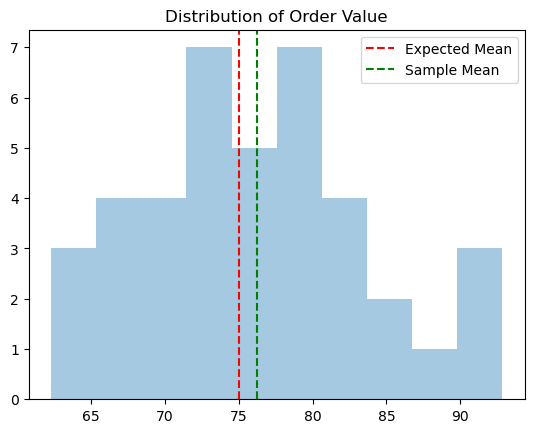

In [19]:
plt.hist(df_order_value['Order_Value'], bins=10, color="#7FB3D5", alpha=0.7)
plt.axvline(75, color='red', linestyle='--', label='Expected Mean')
plt.axvline(df_order_value['Order_Value'].mean(), color='green', linestyle='--', label='Sample Mean')
plt.title("Distribution of Order Value")
plt.legend()
plt.show()

#  Interpretation in Business Terms

Confidence Interval:

“We are 95% confident that the true average order value lies between $73.81 and $78.69.”

Hypothesis Test:

“Since the p-value is  > 0.05, we fail to reject the null hypothesis”

Implications:

“This suggests that there is no strong evidence that the order value is different from the claim. 

In [33]:
# # How to calculate z_value and t_value in z distribution and t distribution

# import math
# import scipy.stats as stats

# # Given data
# x_bar = 50       # sample mean
# mu = 48          # population mean (hypothesized)
# s = 10           # sample standard deviation
# sigma = 9        # population standard deviation (known)
# n = 25           # sample size
# confidence = 0.95

# # ---- Z-Value ----
# z_value = (x_bar - mu) / (sigma / math.sqrt(n))
# print("Z-value:", round(z_value, 3))

# # ---- T-Value ----
# t_value = (x_bar - mu) / (s / math.sqrt(n))
# print("T-value:", round(t_value, 3))

# # ---- Confidence Interval using T-distribution ----
# alpha = 1 - confidence
# df = n - 1
# t_crit = stats.t.ppf(1 - alpha/2, df)
# margin_error_t = t_crit * (s / math.sqrt(n))
# ci_lower_t = x_bar - margin_error_t
# ci_upper_t = x_bar + margin_error_t

# print("\n95% CI using T-distribution:")
# print(f"({ci_lower_t:.2f}, {ci_upper_t:.2f})")

# # ---- Confidence Interval using Z-distribution ----
# z_crit = stats.norm.ppf(1 - alpha/2)
# margin_error_z = z_crit * (sigma / math.sqrt(n))
# ci_lower_z = x_bar - margin_error_z
# ci_upper_z = x_bar + margin_error_z

# print("\n95% CI using Z-distribution:")
# print(f"({ci_lower_z:.2f}, {ci_upper_z:.2f})")